# SCAM IOP Q1/Q2 vertical profiles

Apparent heat source (Q1) and apparent moisture sink (Q2) vertical profiles across the four IOPs (TOGA-COARE, GATE III, ARM 1995, ARM 1997).

- **Rows** — Q1 (top), Q2 (bottom); both in K day⁻¹
- **Columns** — IOP
- **Colour** — CAM vertical resolution (L32, L48, L58, L256)
- **Linestyle** — run type (CAM6 | CAM7 | CAM7 ZM-off)
- **Black dashed** — observed IOP Q1/Q2 (Yanai budget from IOP forcing file)

Observed Q1/Q2 come directly from the IOP forcing files at `/glade/work/rneale/scam_cases/iops` (variables `Q1`, `Q2`, K/s). Model Q1/Q2 are constructed from CAM physics tendencies in `q1q2_utils.py`:

$$Q_1 = \mathrm{DTCOND} + \mathrm{DTV} + \mathrm{QRL} + \mathrm{QRS}$$
$$Q_2 = -\frac{L_v}{C_p}\,(\mathrm{DCQ} + \mathrm{VD01})$$

In [1]:
import os
import glob
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import xarray as xr

from q1q2_utils import compute_model_q1q2, load_obs_q1q2

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

In [2]:
# ── configuration ────────────────────────────────────────────────────────────
BASE_DIR = "/glade/work/rneale/scam_cases/cases/ZM_PBL_paper"
IOP_DIR  = "/glade/work/rneale/scam_cases/iops"
FIG_DIR  = "/glade/work/rneale/git/python-scripts/python-figs/papers/ZM_PBL/"

IOPS       = ["togaII",     "gateIII",  "arm95",    "arm97"]
IOP_LABELS = ["TOGA-COARE", "GATE III", "ARM 1995", "ARM 1997"]

IOP_OBS_FILES = {
    "togaII":  "TOGAII_4scam.nc",
    "gateIII": "GATEIII_4scam.nc",
    "arm95":   "ARM95_4scam.nc",
    "arm97":   "ARM97_4scam.nc",
}

RUN_TYPES  = ["cam6-phys.000", "cam7-phys.000", "cam7-phys.001"]
RUN_LABELS = ["CAM6",          "CAM7",          "CAM7-CAM6phys"]

LEVELS = ["L32", "L48", "L58", "L256"]

# Wong 2011 colorblind-safe palette (matches scam_composite_scatter.ipynb)
_LEVEL_COLORS = {
    "L32":  "#0072B2",   # blue
    "L48":  "#009E73",   # bluish green
    "L58":  "#E69F00",   # orange
    "L256": "#D55E00",   # vermillion
}

_RUNTYPE_LINESTYLES = {
    "cam6-phys.000": "-",
    "cam7-phys.000": "-",
    "cam7-phys.001": ":",
}

SEC_PER_DAY = 86_400.0

In [3]:
# ── helpers ──────────────────────────────────────────────────────────────────

def find_h0i_file(iop, run_type, level):
    case_dir = os.path.join(BASE_DIR, f"FSCAM.T42_T42.{iop}.{run_type}.{level}", "run")
    matches = glob.glob(os.path.join(case_dir, "*.cam.h0i.*.nc"))
    return matches[0] if matches else None


_STAT_REDUCE = {
    "mean": lambda a, axis: np.nanmean(a, axis=axis),
    "min":  lambda a, axis: np.nanmin (a, axis=axis),
    "max":  lambda a, axis: np.nanmax (a, axis=axis),
    "std":  lambda a, axis: np.nanstd (a, axis=axis),
}

In [4]:
# ── 2×4 Q1/Q2 profile plot ───────────────────────────────────────────────────
# Rows: Q1 (top), Q2 (bottom)
# Cols: one per IOP
# Colour = vertical resolution, linestyle = run type, obs = black dashed.

def make_q1q2_profile_plot(stat="mean",
                           plev_min=100, plev_max=1000,
                           obs=True,
                           run_types=None, levels=None,
                           outfile=None, outdir=None,
                           figsize=(16.5, 12.0), wspace=0.05, hspace=0.14,
                           xlim_q1=None, xlim_q2=None):
    """2-row (Q1, Q2) × 4-col (IOP) profile figure in K day⁻¹."""
    if stat not in _STAT_REDUCE:
        raise ValueError(f"stat must be one of {list(_STAT_REDUCE)}; got {stat!r}")
    reduce_fn = _STAT_REDUCE[stat]

    plot_run_types = list(run_types) if run_types else list(RUN_TYPES)
    plot_levels    = list(levels)    if levels    else list(LEVELS)

    fig, axes = plt.subplots(
        2, len(IOPS), sharey=True, figsize=figsize,
        gridspec_kw={"wspace": wspace, "hspace": hspace},
    )

    obs_plotted_any = False

    for col, (iop, iop_label) in enumerate(zip(IOPS, IOP_LABELS)):
        ax_q1 = axes[0, col]
        ax_q2 = axes[1, col]

        # ── model Q1/Q2 (built from CAM tendencies) ───────────────────────
        for rt in plot_run_types:
            ls = _RUNTYPE_LINESTYLES[rt]
            for level in plot_levels:
                fpath = find_h0i_file(iop, rt, level)
                if fpath is None:
                    continue
                try:
                    q1, q2, pres, _ = compute_model_q1q2(fpath)
                except Exception as err:
                    print(f"skip {iop}/{rt}/{level}: {err}")
                    continue

                q1_prof = reduce_fn(q1, axis=0) * SEC_PER_DAY
                q2_prof = reduce_fn(q2, axis=0) * SEC_PER_DAY

                pmask = (pres >= plev_min) & (pres <= plev_max)
                kwargs = dict(color=_LEVEL_COLORS[level], linestyle=ls,
                              linewidth=1.6, alpha=0.9, zorder=3)
                ax_q1.plot(q1_prof[pmask], pres[pmask], **kwargs)
                ax_q2.plot(q2_prof[pmask], pres[pmask], **kwargs)

        # ── observed Q1/Q2 (Yanai budget from IOP forcing file) ───────────
        if obs:
            q1o, q2o, preso = load_obs_q1q2(IOP_DIR, IOP_OBS_FILES[iop])
            if q1o is not None:
                q1o_prof = reduce_fn(q1o, axis=0) * SEC_PER_DAY
                q2o_prof = reduce_fn(q2o, axis=0) * SEC_PER_DAY
                pmask = (preso >= plev_min) & (preso <= plev_max)
                ax_q1.plot(q1o_prof[pmask], preso[pmask],
                           color="k", linestyle="--", linewidth=1.8, zorder=5)
                ax_q2.plot(q2o_prof[pmask], preso[pmask],
                           color="k", linestyle="--", linewidth=1.8, zorder=5)
                obs_plotted_any = True

        # ── axis cosmetics ───────────────────────────────────────────────
        ax_q1.set_title(iop_label, fontsize=14)
        for ax in (ax_q1, ax_q2):
            ax.grid(True, linestyle="--", alpha=0.4)
            ax.set_axisbelow(True)
            ax.tick_params(axis="both", labelsize=10)
            ax.locator_params(axis="x", nbins=4)
            ax.axvline(0.0, color="0.6", linewidth=0.8, zorder=1)

        if xlim_q1 is not None:
            ax_q1.set_xlim(*xlim_q1)
        if xlim_q2 is not None:
            ax_q2.set_xlim(*xlim_q2)

        ax_q2.set_xlabel("K day⁻¹", fontsize=12)

    # y-axis: pressure, inverted, label only on leftmost
    axes[0, 0].set_ylabel("Q1  [hPa]", fontsize=13)
    axes[1, 0].set_ylabel("Q2  [hPa]", fontsize=13)
    for ax in axes.ravel():
        ax.invert_yaxis()
    axes[0, 0].set_ylim(plev_max, plev_min)

    # suptitle
    rt_tag = ""
    if len(plot_run_types) == 1:
        rt_tag = f"  ({RUN_LABELS[RUN_TYPES.index(plot_run_types[0])]})"
    fig.suptitle(
        f"SCAM IOP — {stat} Q1 / Q2 vertical profile{rt_tag}",
        fontsize=16, y=0.965,
    )

    # ── legend ───────────────────────────────────────────────────────────
    def _hdr(text):
        return mlines.Line2D([], [], color="none", label=text)
    def _blank():
        return mlines.Line2D([], [], color="none", label=" ")

    handles = [_hdr("Vert. resolution")]
    for lv in plot_levels:
        handles.append(
            mlines.Line2D([], [], color=_LEVEL_COLORS[lv], linestyle="-",
                          linewidth=1.8, label=f"  {lv}")
        )
    if len(plot_run_types) > 1:
        handles += [_blank(), _hdr("Run type")]
        for rt in plot_run_types:
            handles.append(
                mlines.Line2D([], [], color="0.35",
                              linestyle=_RUNTYPE_LINESTYLES[rt],
                              linewidth=1.8,
                              label=f"  {RUN_LABELS[RUN_TYPES.index(rt)]}")
            )
    if obs and obs_plotted_any:
        handles += [_blank(),
                    mlines.Line2D([], [], color="k", linestyle="--",
                                  linewidth=1.8, label="Observed")]

    fig.subplots_adjust(left=0.07, right=0.86, top=0.92, bottom=0.08,
                        wspace=wspace, hspace=hspace)
    fig.legend(handles=handles,
               bbox_to_anchor=(0.87, 0.90), loc="upper left",
               fontsize=11, framealpha=0.9, borderaxespad=0,
               handletextpad=0.6, labelspacing=0.35)

    # ── save ─────────────────────────────────────────────────────────────
    if outfile is None:
        parts = ["Q1Q2", "profile", f"{int(plev_min)}-{int(plev_max)}hPa", stat]
        if run_types is not None and len(plot_run_types) < len(RUN_TYPES):
            labels = [RUN_LABELS[RUN_TYPES.index(rt)] for rt in plot_run_types]
            parts.append("-".join(labels).replace(" ", ""))
        if levels is not None and len(plot_levels) < len(LEVELS):
            parts.append("-".join(plot_levels))
        outfile = "_".join(parts) + ".png"
    out_all = (outdir or "") + outfile
    fig.savefig(out_all, dpi=150, bbox_inches="tight")
    print(f"Saved → {out_all}")
    plt.show()

Saved → Q1Q2_profile_100-1000hPa_mean.png


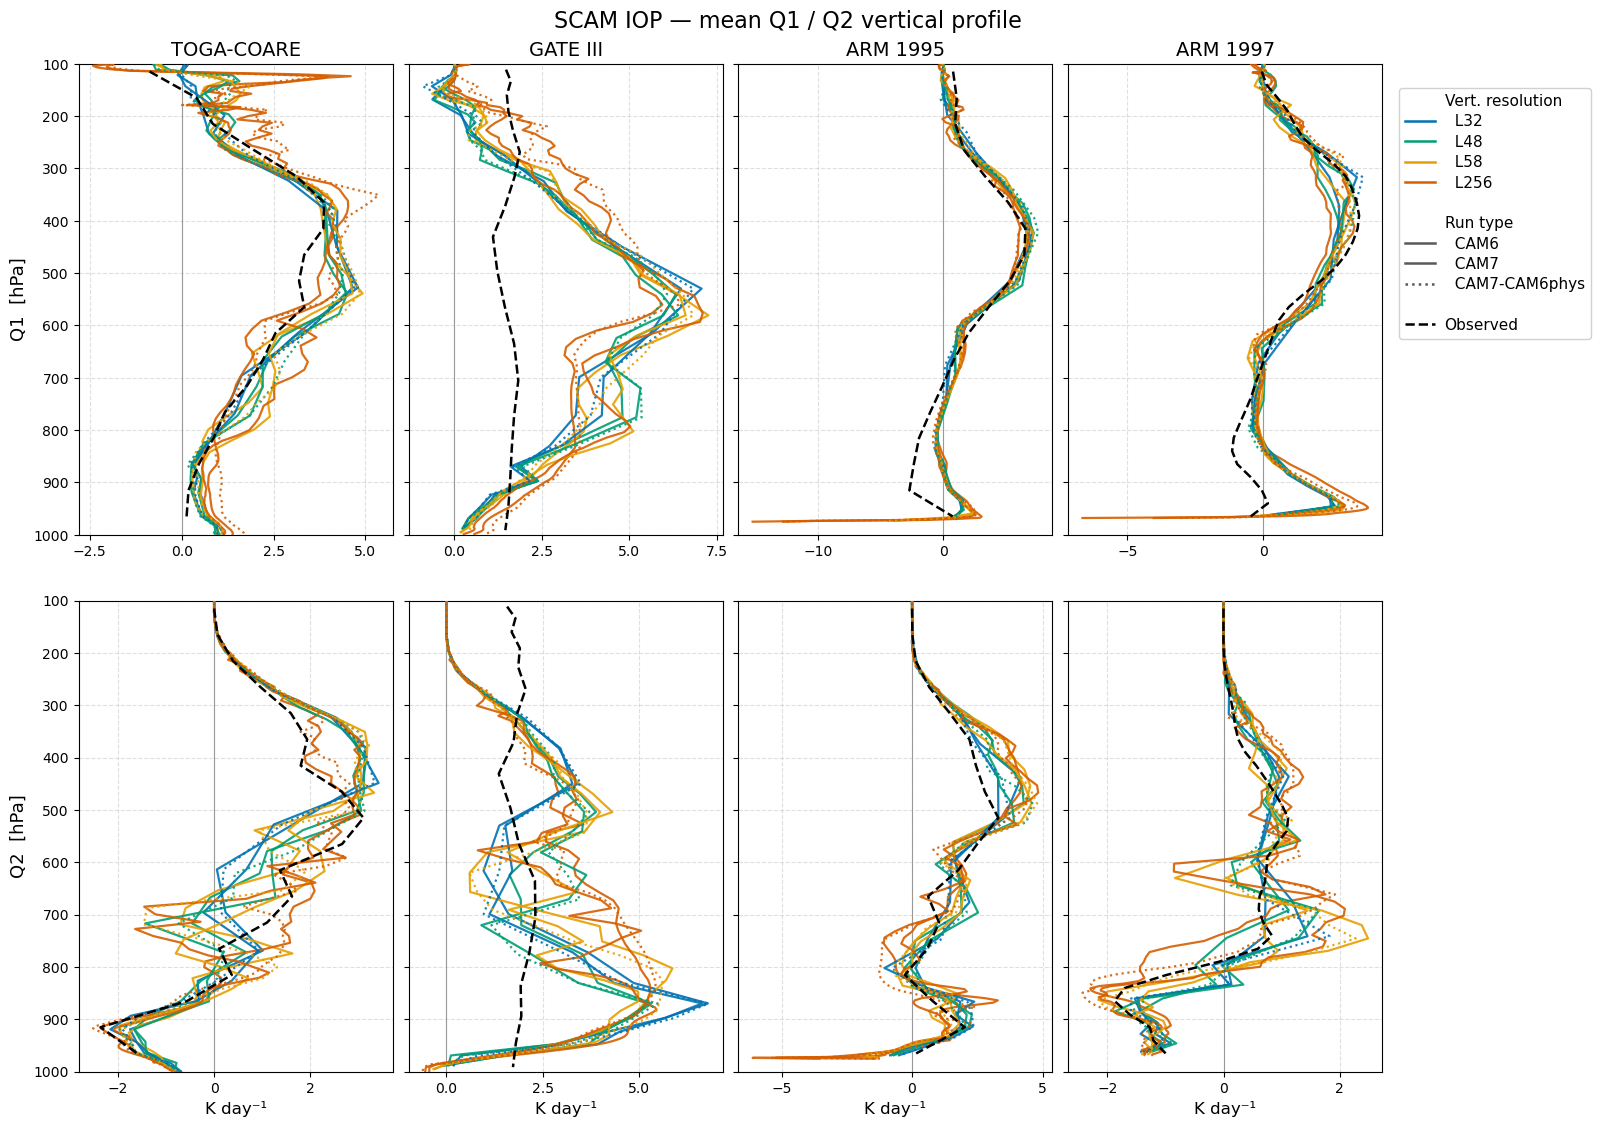

In [5]:
# ── run: time-mean Q1/Q2 profiles, all runs and resolutions ─────────────────
make_q1q2_profile_plot(
    stat="mean",
    plev_min=100, plev_max=1000,
    obs=True,
)

In [6]:
# ── run: CAM7 only, focus on troposphere ─────────────────────────────────────
# make_q1q2_profile_plot(
#     stat="mean",
#     plev_min=150, plev_max=1000,
#     obs=True,
#     run_types=["cam7-phys.000"],
# )

In [ ]:
# ── run: time-std Q1/Q2 profiles ─────────────────────────────────────────────
# make_q1q2_profile_plot(
#     stat="std",
#     plev_min=100, plev_max=1000,
#     obs=True,
# )